# Exercise 1: Classification with US Airline Sentiment Tweets

# Understanding the Problem
We are analyzing the Twitter US Airline Sentiment dataset, which contains approximately 14,640 tweets. Each tweet is mapped to one of three discrete sentiment categories: Negative, Neutral, or Positive.

The core objective is to design, implement, and evaluate a Multi-Layer Feed-Forward Artificial Neural Network (ANN) that processes raw text data and accurately predicts its corresponding sentiment label. This task requires balancing computational efficiency with robust text processing and evaluation strategies to handle potential class imbalances common in social media data.

We need to execute the following sequence:
- Data Preprocessing & EDA.
- Feature Extraction (Vectorization)
- ANN Architecture & Training.
- Performance Metric Evaluation.

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import FastText
from gensim.models import Word2Vec
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.utils.data as data
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns

# NLTK Downloads
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Hardware Acceleration Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
# Load the dataset
file_path = "Tweets.csv"
df = pd.read_csv(file_path)

# Extract the text and the ground truth labels
tweets_df = df[['text', 'airline_sentiment']].copy()

# Check dataset structure and shape
print("Dataset Shape:", tweets_df.shape)
print("\nFirst 5 Rows:")
print(tweets_df.head())

# Calculate class distribution
print("\nClass Counts:")
print(tweets_df['airline_sentiment'].value_counts())

print("\nClass Percentages:")
print(tweets_df['airline_sentiment'].value_counts(normalize=True) * 100)

Dataset Shape: (14640, 2)

First 5 Rows:
                                                text airline_sentiment
0                @VirginAmerica What @dhepburn said.           neutral
1  @VirginAmerica plus you've added commercials t...          positive
2  @VirginAmerica I didn't today... Must mean I n...           neutral
3  @VirginAmerica it's really aggressive to blast...          negative
4  @VirginAmerica and it's a really big bad thing...          negative

Class Counts:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Class Percentages:
airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64


## Insights on the Dataset and Class Distribution

1. Data Dimensions and Features:
The dataset shape is (14640, 2). This means we are processing 14,640 individual airline-related tweets and we successfully extracted two columns: text, which serves as our raw feature matrix, and airline_sentiment, which is our target.

2. Class Imbalance Analysis:
- Negative: 9,178 tweets (~62.69%)
- Neutral: 3,099 tweets (~21.17%)
- Positive: 2,363 tweets (~16.14%)

The distribution reveals a heavy class imbalance, where negative sentiment dominates nearly two-thirds of the entire data. To preserve this distribution across both partitions, stratify=label is applied during the train/test split, ensuring that the 62.6% / 21.2% / 16.1% ratio is maintained in both the training and test sets.

In [4]:
# Step 1: Data Preprocessing & Exploratory Data Analysis (EDA)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet_to_tokens(text: str):
    """
    Cleans raw tweet text by removing URLs, user handles, hashtags, punctuation,
    and digits, followed by lowercasing, tokenization, stopword removal, and lemmatization.
    Args:
        text (str): The raw tweet text string from the dataset.
    Returns:
        list: A list of clean, lemmatized tokens (Necessary for Word2Vec and FastText).
    """
    # Convert to lowercase
    text = text.lower()

    # Remove URLs/Links
    text = re.sub(r'https?://\s*\S+|www\.\S+', '', text)

    # Remove Twitter Handles (@user) and Hashtag symbols (#)
    text = re.sub(r'@\S+', '', text)
    text = re.sub(r'#', '', text)

    # Remove Digits and Numbers
    text = re.sub(r'\d+', '', text)

    # Remove Punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize text to process word by word
    tokens = word_tokenize(text)

    # Filter Stopwords and apply Lemmatization
    clean_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return clean_tokens

# Apply preprocessing to extract token lists
tweets_df['cleaned_tokens'] = tweets_df['text'].apply(clean_tweet_to_tokens)

# Filter out rows that ended up with zero valid tokens post-cleaning
tweets_df = tweets_df[tweets_df['cleaned_tokens'].apply(lambda x: len(x) > 0)]

# Create a string version of the cleaned text specifically for TF-IDF Vectorization
tweets_df['cleaned_text_string'] = tweets_df['cleaned_tokens'].apply(lambda x: " ".join(x))

# Generate sequence length feature for data exploration
tweets_df['token_count'] = tweets_df['cleaned_tokens'].apply(len)

# Print structural validation statistics
print("--- Text Preprocessing Structural Verification ---")
print("Original Tweet :", tweets_df['text'].iloc[3])
print("Cleaned Tokens :", tweets_df['cleaned_tokens'].iloc[3])
print("Cleaned String :", tweets_df['cleaned_text_string'].iloc[3])
print("\nFinal Filtered Dataset Shape:", tweets_df.shape)

--- Text Preprocessing Structural Verification ---
Original Tweet : @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
Cleaned Tokens : ['really', 'aggressive', 'blast', 'obnoxious', 'entertainment', 'guest', 'face', 'amp', 'little', 'recourse']
Cleaned String : really aggressive blast obnoxious entertainment guest face amp little recourse

Final Filtered Dataset Shape: (14620, 5)


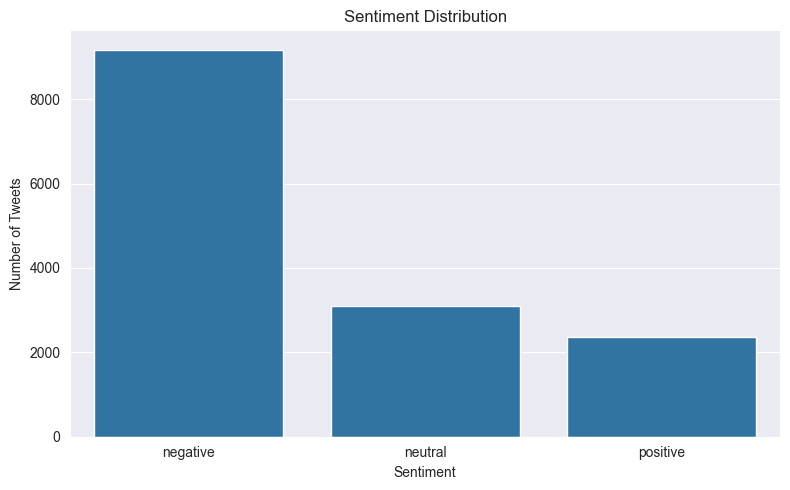

In [5]:
# EDA visualization

plt.figure(figsize=(8, 5))

# Create Bar Chart for the sentiment class distribution
sns.countplot(data=tweets_df, x='airline_sentiment',
              order=['negative', 'neutral', 'positive'])

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')

plt.tight_layout()
plt.show()

## Insights on Sentiments Distribution

- The bar chart clearly illustrates a severe class imbalance within the dataset. The 'Negative' sentiment category dominates the distribution containing over 8000 tweets. In comparison, the 'Neutral' and 'Positive' categories are much smaller.

- Since the majority of the dataset consists of negative examples, any standard Neural Network can easily become biased toward the majority class (negative comments). If a model simply predicts "Negative" for every tweet, it would automatically achieve high accuracy while it may fail to understand the other emotions.

- Because of this clear imbalance, relying solely on global Accuracy to judge our models would be highly misleading. This chart justifies why we must evaluate our classifiers using class-specific metrics like Precision, Recall, and F1-scores, ensuring that the network's ability to identify neutral and positive customer feedback is accurately measured.

In [6]:
# Step 2: Feature Extraction (Vectorization)

# Map categorical text labels to numeric identifiers
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
tweets_df['label'] = tweets_df['airline_sentiment'].map(label_mapping)

# Transform the Data
# Split the dataset into Train and Test sets (80% Train, 20% Test)
X_train_str, X_test_str, y_train, y_test = train_test_split(
    tweets_df['cleaned_text_string'].values,
    tweets_df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=tweets_df['label'].values
)

X_train_tok, X_test_tok, _, _ = train_test_split(
    tweets_df['cleaned_tokens'].values,
    tweets_df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=tweets_df['label'].values
)

In [7]:
# TF-IDF Transformation

# Initializes the vectorizer
tfidf_vec = TfidfVectorizer(max_features=3000)

# Transform Airline Tweets
X_train_tfidf = tfidf_vec.fit_transform(X_train_str).toarray()
X_test_tfidf  = tfidf_vec.transform(X_test_str).toarray()

print(f"TF-IDF Train shape: {X_train_tfidf.shape}")
print(f"TF-IDF Test shape : {X_test_tfidf.shape}")

TF-IDF Train shape: (11696, 3000)
TF-IDF Test shape : (2924, 3000)


## Insights on TF-IDF

TF-IDF Train shape: (11696, 3000):

This means that we have 11,696 rows that represent the number of unique tweets in our training set. Each row is one specific tweet.
We have 3,000 columns/features. This is the "vocabulary" size we defined using the max_features=3000 parameter, which selects the 3,000 most statistically significant words across all airline tweets and turned them into numerical columns based on their frequency.

In [8]:
# FastText Transformation

# Initializes the vectorizer
ft_model = FastText(sentences=X_train_tok, vector_size=100, window=5, min_count=1, workers=4, seed=42)

# Defining helper function
def get_fasttext_vector(model: FastText, tokens: list, vector_size=100):
    """
    Converts a tokenized list of words into a single representative vector by averaging the FastText embeddings.
    Args:
        model (FastText): The trained FastText model from gensim.
        tokens (list): A list of clean, lemmatized tokens for a single tweet.
        vector_size (int): The dimensional size of the embedding vectors.
    Returns:
        ndarray: A 1D numpy array representing the averaged sentence vector.
    """
    valid_vectors = [model.wv[word] for word in tokens]

    if len(valid_vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(valid_vectors, axis=0)

# Transform Airline Tweets
X_train_ft = np.array([get_fasttext_vector(ft_model, tok) for tok in X_train_tok])
X_test_ft  = np.array([get_fasttext_vector(ft_model, tok) for tok in X_test_tok])

print(f"FastText Train shape: {X_train_ft.shape}")
print(f"FastText Test shape : {X_test_ft.shape}")

FastText Train shape: (11696, 100)
FastText Test shape : (2924, 100)


## Insights FastText

FastText Train shape: (11696, 100)

This means that we have 11,696 rows, representing a processed tweet from our dataset.
Unlike TF-IDF, we now have exactly 100 columns/features. Instead of counting explicit word occurrences, the algorithm represents the underlying meaning and semantic context of each tweet in a 100-dimensional vector. This fixed size was defined by our vector_size=100 parameter.

In [9]:
# Word2Vec Transformation

# Initializes the vectorizer
w2v_model = Word2Vec(sentences=X_train_tok, vector_size=100, window=5, min_count=1, workers=4, seed=42)

# Defining helper function
def get_w2v_vector(model: Word2Vec, tokens: list, vector_size=100):
    """
    Converts a tokenized list of words into a single representative vector by averaging the Word2Vec embeddings.
    Args:
        model (Word2Vec): The trained Word2Vec model from gensim.
        tokens (list): A list of clean, lemmatized tokens for a single tweet.
        vector_size (int): The dimensional size of the embedding vectors.
    Returns:
        ndarray: A 1D numpy array representing the averaged sentence vector.
    """
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(valid_vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(valid_vectors, axis=0)

# Transform Airline Tweets
X_train_w2v = np.array([get_w2v_vector(w2v_model, tok) for tok in X_train_tok])
X_test_w2v  = np.array([get_w2v_vector(w2v_model, tok) for tok in X_test_tok])

print(f"Word2Vec Train shape: {X_train_w2v.shape}")
print(f"Word2Vec Test shape : {X_test_w2v.shape}")

Word2Vec Train shape: (11696, 100)
Word2Vec Test shape : (2924, 100)


## Insights on Word2Vec

Word2Vec Train shape: (11696, 100)

This means that we have 11,696 rows representing our training dataset vectors. Similar to FastText, it gives a dense matrix of 100 features. The primary difference is that Word2Vec looks at whole words to build context , making it effective at capturing explicit semantic associations.

# Justification of Hyperparameter Selection

The training hyperparameters for our Artificial Neural Network (ANN) were chosen based on the course slides:

- max_features = 3000 (TF-IDF): this parameter limits the total number of features included in our final matrix. Setting it to 3,000 allows us to keep high-frequency, sentiment-carrying words while dropping rare terms and noise, making data loading and text mapping more efficient.

- hidden_dim = 128 (Number of Neurons): the number of nodes in the hidden layer defines the capacity and complexity of the network. Choosing 128 nodes is a balanced "rule of thumb" to avoid underfitting and overfitting.

- dropout = 0.3: Dropout is a powerful regularization technique used to reduce overfitting and improve generalization. A rate of 0.3 means we randomly deactivate 30% of the neurons during training, which forces the network to learn patterns instead of memorizing the training data.

- Learning Rate (lr) = 0.001: it controls how big of a step we take in the gradient's direction.

- batch_size = 64: it is recommended to start with the standard default values of 32 or 64 to ensure proper weight updates.

In [10]:
# Step 3: Build the ANN Classifier
class TweetVectorDataset(data.Dataset):
    """
    Custom Dataset to wrap text feature matrices and label arrays for PyTorch DataLoader.
    Args:
        X_data (ndarray): The input feature matrix (TF-IDF or Embeddings).
        y_data (ndarray): The target labels array.
    """
    def __init__(self, X_data, y_data):
        # Convert numpy arrays directly into PyTorch float and long tensors
        self.X = torch.tensor(X_data, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class AirlineSentimentANN(nn.Module):
    """
    Multi-layer feed-forward Neural Network with Dropout regularization for multi-class classification.
    Args:
        input_dim (int): The number of features in the input vector.
        hidden_dim (int): The number of neurons in the first hidden layer.
        output_dim (int): The number of target output classes (3 for sentiment).
        dropout_rate (float): The probability of neuron deactivation for regularization.
    """
    def __init__(self, input_dim, hidden_dim=128, output_dim=3, dropout_rate=0.3):
        super(AirlineSentimentANN, self).__init__()

        # Input Layer to Hidden Layer 1
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=dropout_rate)

        # Hidden Layer 1 to Hidden Layer 2
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=dropout_rate)

        # Hidden Layer 2 to Output Layer (3 units for Negative, Neutral, Positive)
        self.output_layer = nn.Linear(hidden_dim // 2, output_dim)

    def forward(self, x):
        # Forward pass pipeline execution
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.fc2(out)
        out = self.relu2(out)
        out = self.dropout2(out)

        # Returns raw logits. PyTorch's nn.CrossEntropyLoss applies Softmax automatically.
        out = self.output_layer(out)
        return out

print("PyTorch Dataset and ANN Architecture classes established successfully.")

PyTorch Dataset and ANN Architecture classes established successfully.


In [11]:
# Early Stopping in order the model to stop if the performance does not improve.
class EarlyStopping:
    """
    Tracks validation loss across training epochs and stops execution if performance plateaus.

    Args:
        patience (int): Number of epochs to wait after min validation loss before stopping.
        min_delta (float): Minimum change in monitored value to qualify as an improvement.
        checkpoint_path (str): File path where the best model weights will be saved.
    """
    def __init__(self, patience=5, min_delta=0.0, checkpoint_path='best_model.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.checkpoint_path = checkpoint_path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        # First epoch stabilization
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        # Check if validation loss failed to improve significantly
        elif val_loss >= self.best_loss - self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        # Validation loss improved, reset counter and save weights
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        """
        Saves the current model weights to a file when validation loss improves.

        Args:
            model (nn.Module): The PyTorch neural network model to back up.
        """
        torch.save(model.state_dict(), self.checkpoint_path)

In [12]:
# Monitor validation loss in each epoch
def train_and_validate_model(model, train_loader, test_loader, criterion, optimizer, early_stopping, epochs=50):
    """
    Trains the neural network and monitors both training and validation loss per epoch,
    incorporating early stopping to prevent overfitting.

    Args:
        model (nn.Module): The ANN classifier architecture to train.
        train_loader (DataLoader): PyTorch DataLoader for the training dataset partition.
        test_loader (DataLoader): PyTorch DataLoader for the validation dataset partition.
        criterion (nn.Module): The loss function (CrossEntropyLoss for multi-class).
        optimizer (optim.Optimizer): The optimization algorithm.
        early_stopping (EarlyStopping): Object instance managing the early stopping logic.
        epochs (int): The maximum number of training iterations allowed.
    Returns:
        tuple: Lists containing training and validation losses recorded per epoch.
    """
    train_losses = []
    val_losses = []

    for epoch in range(1, epochs + 1):
        # Training Phase
        model.train()
        running_train_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation Phase
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

        epoch_val_loss = running_val_loss / len(test_loader.dataset)
        val_losses.append(epoch_val_loss)

        # Print metrics to monitor performance during execution
        print(f"Epoch {epoch:02d}/{epochs} -> Train Loss: {epoch_train_loss:.4f} | Validation Loss: {epoch_val_loss:.4f}")

        # Check Early Stopping criteria
        early_stopping(epoch_val_loss, model)
        if early_stopping.early_stop:
            print(f"Training halted early at epoch {epoch} due to validation loss stabilization.")
            break

    return train_losses, val_losses

In [13]:
# Εxperimentation with the layers and neurons

# Create PyTorch Dataset instances for each vectorization method

# TF-IDF Datasets
train_dataset_tfidf = TweetVectorDataset(X_train_tfidf, y_train)
test_dataset_tfidf  = TweetVectorDataset(X_test_tfidf, y_test)

# FastText Datasets
train_dataset_ft = TweetVectorDataset(X_train_ft, y_train)
test_dataset_ft  = TweetVectorDataset(X_test_ft, y_test)

# Word2Vec Datasets
train_dataset_w2v = TweetVectorDataset(X_train_w2v, y_train)
test_dataset_w2v  = TweetVectorDataset(X_test_w2v, y_test)

# Standard batch sizing
batch_size = 64

train_loader_tfidf = data.DataLoader(train_dataset_tfidf, batch_size=batch_size, shuffle=True)
test_loader_tfidf  = data.DataLoader(test_dataset_tfidf, batch_size=batch_size, shuffle=False)

train_loader_ft = data.DataLoader(train_dataset_ft, batch_size=batch_size, shuffle=True)
test_loader_ft  = data.DataLoader(test_dataset_ft, batch_size=batch_size, shuffle=False)

train_loader_w2v = data.DataLoader(train_dataset_w2v, batch_size=batch_size, shuffle=True)
test_loader_w2v  = data.DataLoader(test_dataset_w2v, batch_size=batch_size, shuffle=False)

print("All PyTorch DataLoaders successfully configured.")

All PyTorch DataLoaders successfully configured.


In [14]:
# Dictionary to store the loss history for analysis and plotting later
loss_histories = {}

# Define configurations for our experiment across vectorizers
experiments = {
    "TF-IDF": {
        "train_loader": train_loader_tfidf,
        "test_loader": test_loader_tfidf,
        "input_dim": 3000
    },
    "FastText": {
        "train_loader": train_loader_ft,
        "test_loader": test_loader_ft,
        "input_dim": 100
    },
    "Word2Vec": {
        "train_loader": train_loader_w2v,
        "test_loader": test_loader_w2v,
        "input_dim": 100
    }
}

# Execute the training pipeline sequentially
for name, config in experiments.items():
    print()
    print(f"Starting Training: {name}")

    # Initialize architecture with a standard stable neurons layout
    model = AirlineSentimentANN(input_dim=config["input_dim"], hidden_dim=128, dropout_rate=0.3).to(device)

    # Establish optimization criterion and optimizer algorithm
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Initialize early stopping monitor specific to this pipeline execution
    early_stopper = EarlyStopping(patience=5, checkpoint_path=f'best_model_{name.lower()}.pt')

    # Train and monitor validation loss
    train_loss, val_loss = train_and_validate_model(
        model=model,
        train_loader=config["train_loader"],
        test_loader=config["test_loader"],
        criterion=criterion,
        optimizer=optimizer,
        early_stopping=early_stopper,
        epochs=30
    )

    # Store histories for global visualization
    loss_histories[name] = {"train": train_loss, "val": val_loss}


Starting Training: TF-IDF
Epoch 01/30 -> Train Loss: 0.7878 | Validation Loss: 0.6013
Epoch 02/30 -> Train Loss: 0.4948 | Validation Loss: 0.5328
Epoch 03/30 -> Train Loss: 0.3991 | Validation Loss: 0.5524
EarlyStopping counter: 1 out of 5
Epoch 04/30 -> Train Loss: 0.3440 | Validation Loss: 0.5954
EarlyStopping counter: 2 out of 5
Epoch 05/30 -> Train Loss: 0.2985 | Validation Loss: 0.6262
EarlyStopping counter: 3 out of 5
Epoch 06/30 -> Train Loss: 0.2587 | Validation Loss: 0.6927
EarlyStopping counter: 4 out of 5
Epoch 07/30 -> Train Loss: 0.2201 | Validation Loss: 0.7450
EarlyStopping counter: 5 out of 5
Training halted early at epoch 7 due to validation loss stabilization.

Starting Training: FastText
Epoch 01/30 -> Train Loss: 0.9106 | Validation Loss: 0.8769
Epoch 02/30 -> Train Loss: 0.8834 | Validation Loss: 0.8646
Epoch 03/30 -> Train Loss: 0.8747 | Validation Loss: 0.8580
Epoch 04/30 -> Train Loss: 0.8637 | Validation Loss: 0.8504
Epoch 05/30 -> Train Loss: 0.8596 | Validat

## Training Performance Insights across Vectorization Methods

1. TF-IDF Vectorization Pipeline
- The model trained on TF-IDF features converged very fast. The Early Stopping mechanism stopped the training at Epoch 7.
- The training loss dropped smoothly from 0.7878 to 0.2201. However, the validation loss reached its lowest point at Epoch 2 (0.5328) and then started to increase again, reaching 0.7450, meaning that the model started overfitting. The best weights were saved at Epoch 2 and restored for evaluation.

2. FastText Vectorization Pipeline
- FastText showed a slow and stable training process, with the Early Stopping mechanism halting training at Epoch 18.
- The training loss decreased gradually from 0.9106 to 0.8295, and the validation loss reached its minimum at Epoch 13 (0.8202). The persistently high loss values indicate that compressing the text into 100-dimensional averaged vectors made it difficult for the network to separate the sentiment classes. The model did not show any overfitting.

3. Word2Vec Vectorization Pipeline
- Word2Vec showed a steady learning curve, completing all 30 training epochs without triggering early termination.
- The training loss decreased gradually from 0.9239 to 0.7752, and the validation loss reached its best performance at Epoch 28 (0.7700). By focusing on full words rather than sub-words, Word2Vec captured the specific vocabulary of airline reviews effectively, delivering the best overall balance among the embedding methods without any overfitting issues.

## Summary and Final Conclusions

1. TF-IDF: This method is powerful but easily leads to overfitting. Because it creates a large number of features (3,000 columns), the network tends to memorize specific words from the training data instead of learning general meanings. This is why the Early Stopping mechanism halted training at Epoch 7, saving the best weights from Epoch 2.

2. FastText: This method is stable and does not suffer from overfitting. However, it compresses the text too much into 100-dimensional averaged vectors, which makes it harder for the network to clearly separate the different sentiment categories, resulting in high loss values throughout training.

3. Word2Vec: This method gives the most balanced and stable results among the embedding methods. By focusing on whole words within the specific context of airline tweets, it helps the neural network learn effectively and reduce its errors steadily across all 30 epochs, without any overfitting problems.

In [15]:
# Step 4: Performance Metrics

# Function to generate predictions using the best saved weights
def evaluate_saved_model(checkpoint_path, test_loader, input_dim):
    """
    Loads the best saved weights for a model, executes predictions on the test dataset,
    and returns true labels alongside predicted classes.
    Args:
        checkpoint_path (str): File path to the saved state dictionary (.pt file).
        test_loader (DataLoader): PyTorch DataLoader for the test set partitions.
        input_dim (int): Input feature size corresponding to the vectorizer used.
    Returns:
        tuple: Arrays of true labels and predicted labels.
    """
    # Re-initialize the architecture
    model = AirlineSentimentANN(input_dim=input_dim, hidden_dim=128, dropout_rate=0.3).to(device)

    # Load the saved state dictionary
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            # Get the index of the highest logit score (predicted class)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)


Report for TF-IDF Vectorization:
              precision    recall  f1-score   support

    Negative       0.84      0.91      0.87      1834
     Neutral       0.64      0.54      0.58       618
    Positive       0.75      0.66      0.70       472

    accuracy                           0.79      2924
   macro avg       0.74      0.70      0.72      2924
weighted avg       0.78      0.79      0.78      2924


Report for FastText Vectorization:
              precision    recall  f1-score   support

    Negative       0.67      0.97      0.79      1834
     Neutral       0.51      0.17      0.25       618
    Positive       0.57      0.10      0.17       472

    accuracy                           0.66      2924
   macro avg       0.58      0.41      0.41      2924
weighted avg       0.62      0.66      0.58      2924


Report for Word2Vec Vectorization:
              precision    recall  f1-score   support

    Negative       0.69      0.95      0.80      1834
     Neutral       0.49

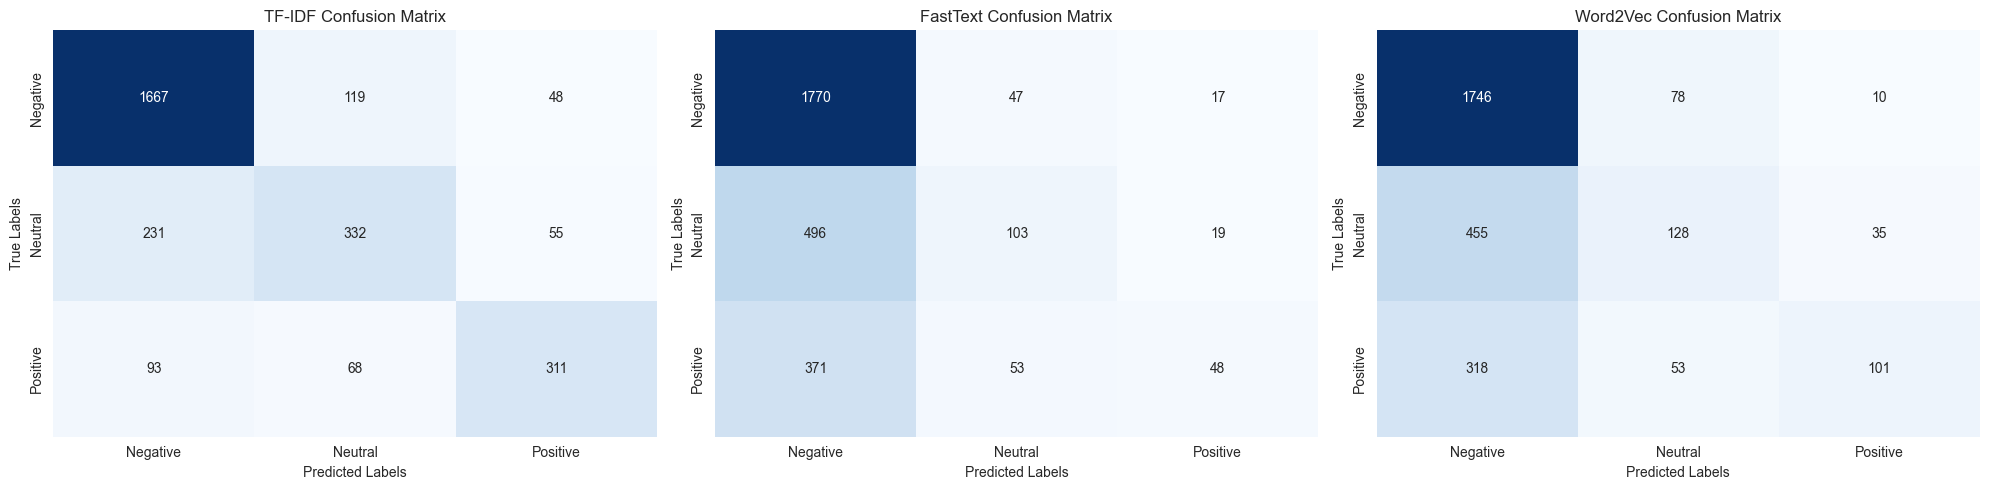

In [16]:
# Execution and Visualization
saved_experiments = {
    "TF-IDF": {"path": "best_model_tf-idf.pt", "loader": test_loader_tfidf, "dim": 3000},
    "FastText": {"path": "best_model_fasttext.pt", "loader": test_loader_ft, "dim": 100},
    "Word2Vec": {"path": "best_model_word2vec.pt", "loader": test_loader_w2v, "dim": 100}
}

# Standard target names mapped back to text for clear presentation
class_names = ['Negative', 'Neutral', 'Positive']

# Confusion Matriχes
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, (name, config) in enumerate(saved_experiments.items()):
    y_true, y_pred = evaluate_saved_model(config["path"], config["loader"], config["dim"])

    # Print Classification Report with standard accuracy, precision, recall, and F1
    print(f"\nReport for {name} Vectorization:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    # Generate a Confusion Matrix array
    cm = confusion_matrix(y_true, y_pred)

    # Plot Heatmap visualization
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_ylabel('True Labels')
    axes[idx].set_xlabel('Predicted Labels')

plt.tight_layout()
plt.show()

## Insights on Model Evaluation and Performance Metrics

1. Accuracy Analysis
- The TF-IDF vectorization configuration achieved the highest overall performance with accuracy of 79%. Word2Vec followed with 68%, and FastText recorded the lowest overall accuracy at 66%.
- Although TF-IDF showed a strong tendency to overfit during training, the Early Stopping monitor successfully intervened at Epoch 7, saving the best weights from Epoch 2. This prevented the model from degrading on unseen test data.


2. Class Imbalance on Word2Vec & FastText
- The dataset is heavily imbalanced, as Negative tweets dominate the support distribution (~62.6%). This distribution had a major impact on both Word2Vec and FastText.
- Both embedding pipelines scored a very high Recall for the Negative class (0.95 for Word2Vec and 0.97 for FastText). This means they correctly identified almost all negative tweets. However, they did this by frequently predicting the "Negative" label for Neutral and Positive tweets as well.
- As a result of this bias, their performance on the minority classes dropped significantly. For instance, FastText achieved a Recall of just 17% for Neutral tweets and only 10% for Positive, while Word2Vec reached only 21% for both Neutral and Positive.


3. Strengths of TF-IDF
- TF-IDF managed the class imbalance much better. It achieved high F1-scores across all metrics: 0.87 for Negative, 0.58 for Neutral, and 0.70 for Positive tweets.
- In product or service datasets like airline tweets, sentiment is often tied to specific, high-impact words. TF-IDF isolates and weights these specific indicator words directly, allowing the neural network to build sharper, more effective decision boundaries than averaged 100-dimensional dense vectors.

# Insights on Confusion Matrixes

1. TF-IDF Confusion Matrix:

- This model shows a well-distributed diagonal, which represents correct predictions. It correctly classified 1,667 Negative, 332 Neutral, and 311 Positive tweets. The confusion between neighboring classes is kept at a minimum compared to the other models, confirming that TF-IDF builds sharper decision boundaries across all three sentiment categories.

2. FastText and Word2Vec Confusion Matrices:
- Both dense embedding matrices show a heavy vertical concentration in the first column ('Negative'). FastText misclassified 496 Neutral and 371 Positive tweets as Negative, while Word2Vec misclassified 455 Neutral and 318 Positive tweets as Negative.
- While they successfully capture 'Negative' tweets (1,770 and 1,746 correct respectively), they struggle severely with minority classes. This visually demonstrates how the 100-dimensional averaged embeddings failed to find clear boundaries to separate Neutral and Positive sentiments under a skewed class distribution.

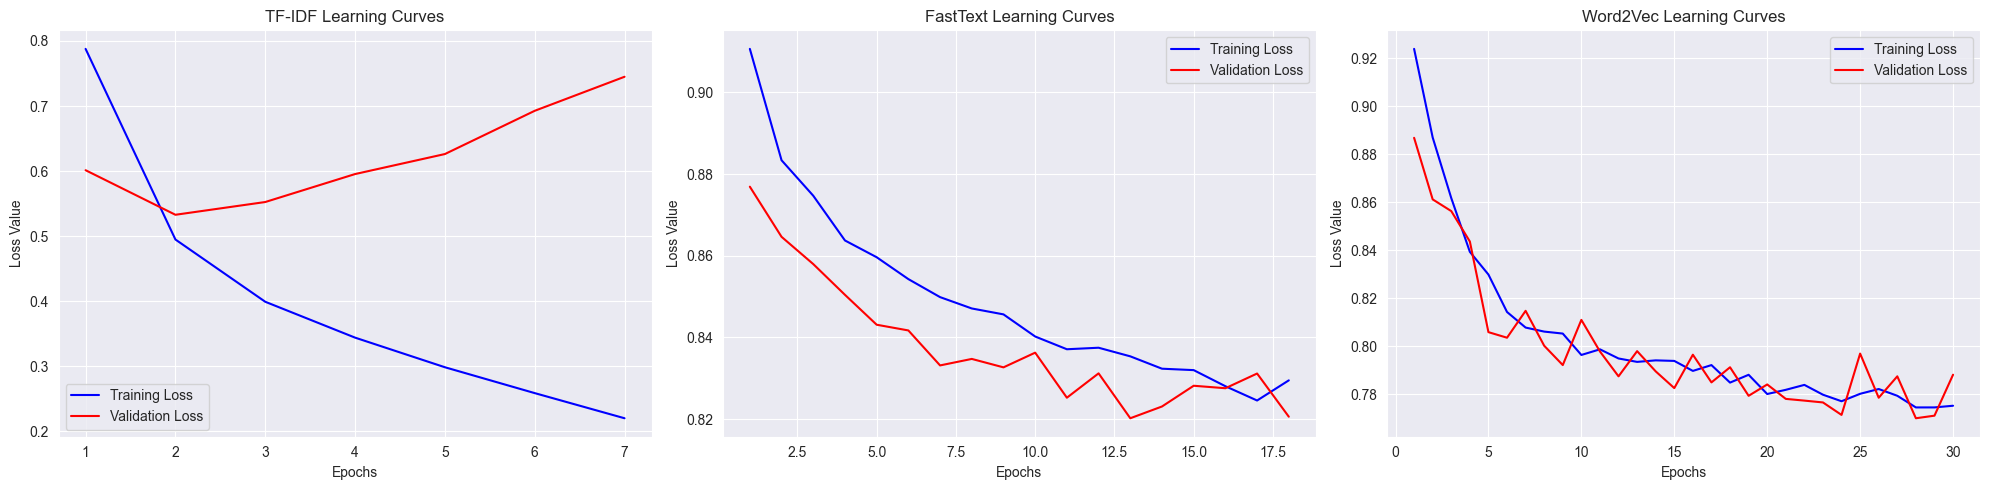

In [17]:
# Visualization

# Loss Curve to be plotted
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Define the models in the exact order they were trained
for idx, name in enumerate(["TF-IDF", "FastText", "Word2Vec"]):
    train_loss_coords = loss_histories[name]["train"]
    val_loss_coords = loss_histories[name]["val"]
    epochs_range = range(1, len(train_loss_coords) + 1)

    # Plot Training Loss curve
    axes[idx].plot(epochs_range, train_loss_coords, label='Training Loss', color='blue')
    # Plot Validation Loss curve
    axes[idx].plot(epochs_range, val_loss_coords, label='Validation Loss', color='red')

    axes[idx].set_title(f'{name} Learning Curves')
    axes[idx].set_xlabel('Epochs')
    axes[idx].set_ylabel('Loss Value')
    axes[idx].legend()
    axes[idx].grid(True)

plt.tight_layout()
plt.show()

## Insights on Training Loss Curves

1. TF-IDF Learning Curves:
- The chart visually confirms why the Early Stopping mechanism intervened at Epoch 7. While the blue line (Training Loss) drops smoothly toward zero, the red line (Validation Loss) hits its lowest point at Epoch 2 (0.5328) and then keeps climbing upward. This is a clear sign of overfitting — the model started memorizing specific training words instead of learning general sentiment patterns, making early termination necessary to save the best weights.

2. FastText Learning Curves:
- FastText shows a stable and consistent descent for both training and validation loss, with the two lines tracking closely together until Early Stopping halted training at Epoch 18. The absence of a significant gap between the two curves confirms that no overfitting occurred, though the persistently high loss values reflect the difficulty of separating sentiment classes from 100-dimensional averaged vectors.

3. Word2Vec Learning Curves:
- Word2Vec completed all 30 epochs, showing a steady downward trend for both curves. The validation loss displays more fluctuation compared to FastText, but overall follows the training loss without diverging, confirming no overfitting. The gradual improvement across epochs reflects Word2Vec's ability to capture word-level context progressively.